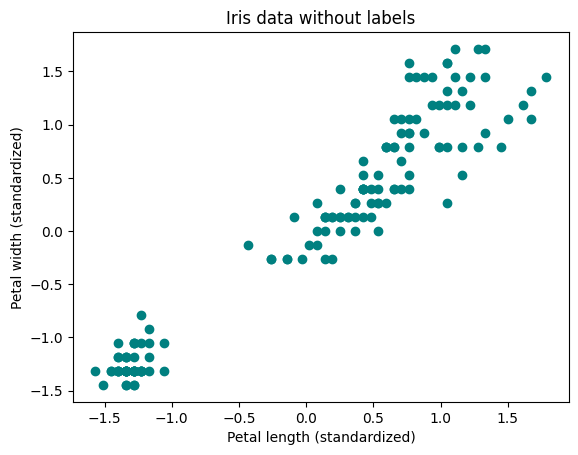

In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np # 추가

iris = load_iris()

# 꽃잎 길이와 꽃잎 너비만 선택
X = iris.data[:, 2:4]

# 특징값의 크기를 비슷한 기준으로 맞춤
X_scaled = StandardScaler().fit_transform(X)

# 정답 정보 없이 데이터 모양 확인
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], color="teal")
plt.xlabel("Petal length (standardized)")
plt.ylabel("Petal width (standardized)")
plt.title("Iris data without labels")
plt.show()

In [2]:
K = 3 # k 설정

# 처음 중심점(Centroid) 랜덤으로 선택
np.random.seed(42) # 랜덤으로 뽑기는 하는데 항상 같은 랜덤 결과가 나오도록 고정

indices = np.random.choice(
    len(X_scaled),
    K,
    replace=False
)

centers = X_scaled[indices] # 랜덤으로 나온 번호에 해당하는 꽃 데이터를 실제로 가져오고
# 그 3개의 꽃의 위치를 임시 중심점 3곳으로 잡고 이제 시작

In [3]:
# K-Means 반복
max_iter = 100

for i in range(max_iter):

    # 1. 각 중심점까지의 거리 계산
    distances = np.zeros((len(X_scaled), K)) # 거리값을 넣을 빈표를 만든다.
    # np.zeros(): 0으로 채워진 배열을 만드는 함수

    for k in range(K):
        distances[:, k] = np.sqrt(
            np.sum((X_scaled - centers[k]) ** 2, axis=1)
        ) # 모든 데이터와 k번째 중심점 사이의 거리를 계산해서 저장

    # 2. 가장 가까운 중심점의 그룹에 배정
    clusters = np.argmin(distances, axis=1) # argmin: 가장 작은 값의 위치를 찾아주는 함수


    # 3. 새로운 중심점 계산
    new_centers = np.zeros_like(centers) # 기존 centers와 똑같은 크기의 빈 표를 만든다

    # k(0,1,2)번 그룹에 속한 데이터들의 평균을 구해서 새로운 중심점으로 만든다.
    for k in range(K):
        new_centers[k] = X_scaled[clusters == k].mean(axis=0)
        # X_scaled[clusters == k]: k번 Cluster에 속한 데이터만 가져와라.
        # .mean(axis=0): 그 데이터들의 평균 위치를 구한다.

    # 4. 중심점이 더 이상 거의 움직이지 않으면 종료
    if np.allclose(centers, new_centers):
        break
    # np.allclose() = 두 값이 거의 같은지 확인
    # break = 반복문 즉시 종료

    centers = new_centers
    # 중심점이 아직 다르다면, 새로 구한 중심점을 현재 중심점으로 교체하고 다시 for문 반복

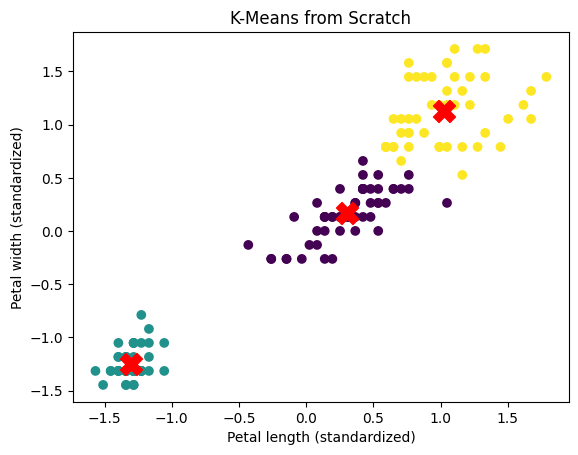

In [4]:
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap="viridis"
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    color="red"
)

plt.xlabel("Petal length (standardized)")
plt.ylabel("Petal width (standardized)")
plt.title("K-Means from Scratch")
plt.show()